<a href="https://colab.research.google.com/github/RezzaHarya/Data-Scientist-Exploratory-Data-Analysis/blob/main/Copy_of_Modul_Pelatiha__Pert_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## import library

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

## Load Dataset

In [20]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

#Tampilkan 5 baris pertama
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Understanding

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [22]:
#Tampilkan statistik dari dataset
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [23]:
# melihat dan menghitung column serta baris kosong
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## EDA

### Univariate

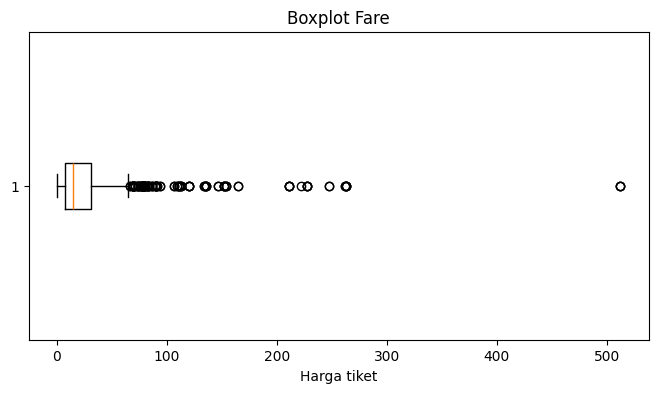

In [24]:
plt.figure(figsize=(8, 4))
#Tampilkan Fare menggunakan Boxplot
plt.boxplot(df['Fare'], vert=False)
plt.title('Boxplot Fare')
plt.xlabel('Harga tiket')
plt.show()

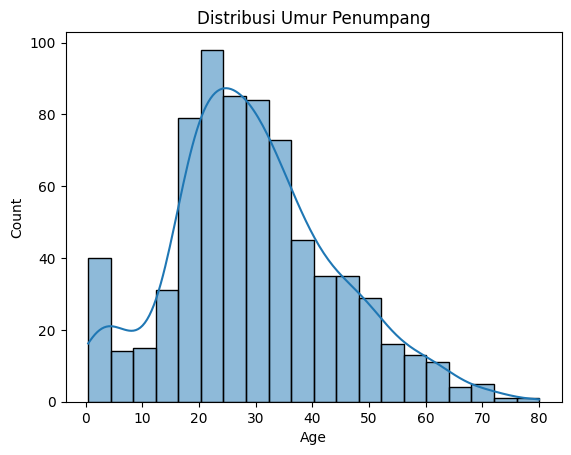

In [25]:
sns.histplot(df['Age'], kde=True)
#tampilkan judulnya menggunakan fitur dari matplotlib
plt.title("Distribusi Umur Penumpang")
plt.show()

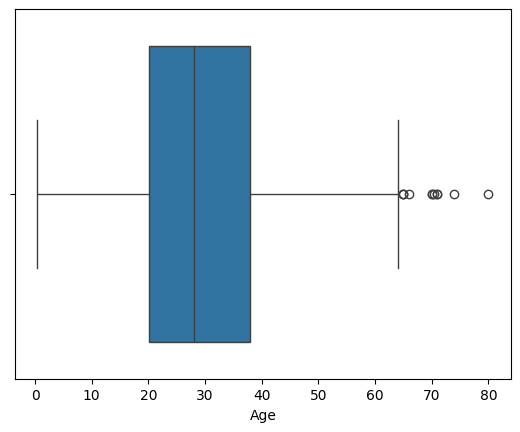

In [26]:
sns.boxplot(x=df['Age'])
#Tampilkan boxplotnya
plt.show()

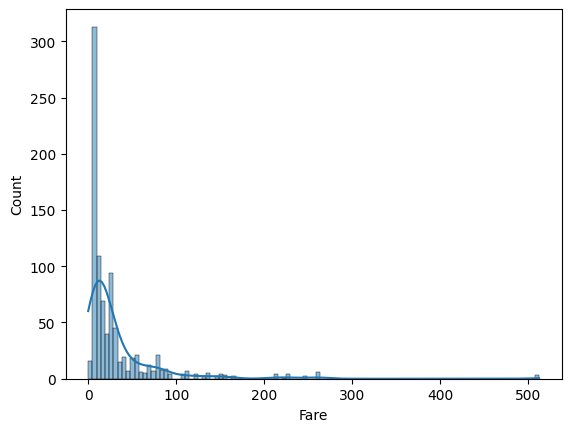

In [27]:
sns.histplot(df['Fare'], kde=True)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

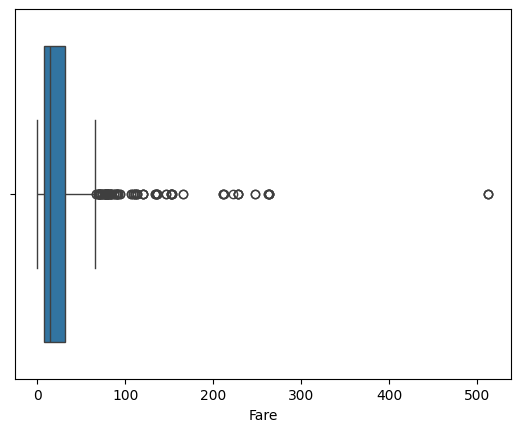

In [28]:
sns.boxplot(x=df['Fare'])
plt.show

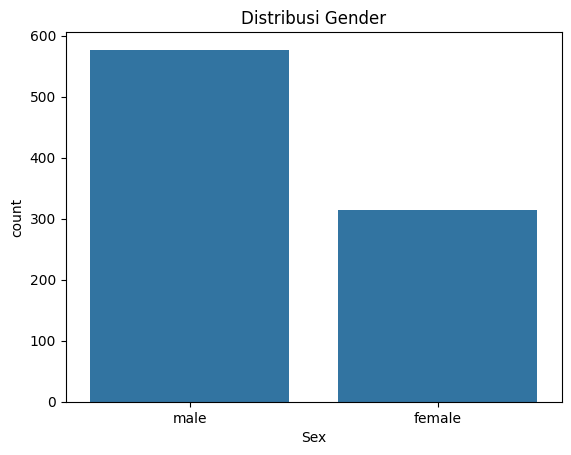

In [29]:
#Tampilkan Sex pada countplot
sns.countplot(x=df['Sex'])
plt.title("Distribusi Gender")
plt.show()

### Bivariate

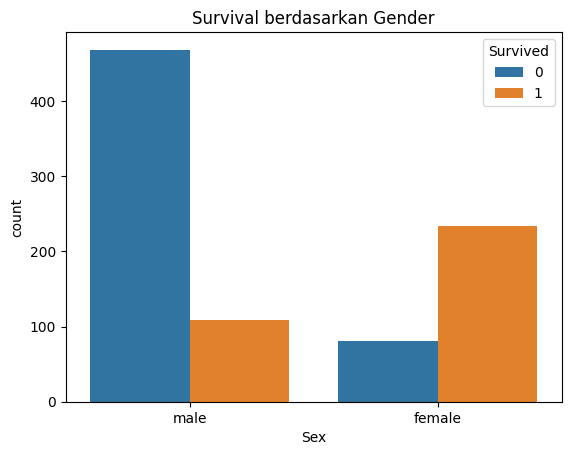

In [30]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival berdasarkan Gender")
plt.show()

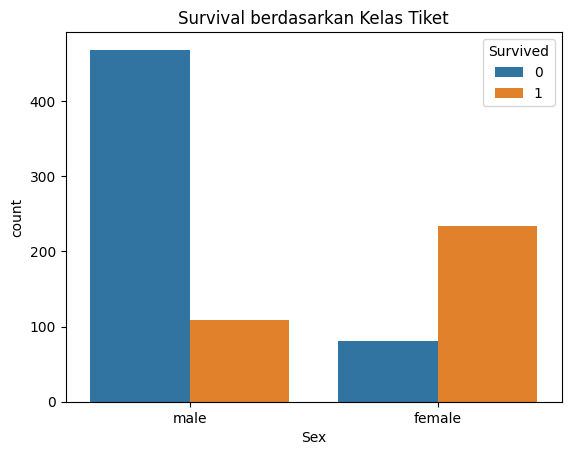

In [31]:
#Tampilkan hubungan antaran Pclass dengan survived
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival berdasarkan Kelas Tiket")
plt.show()

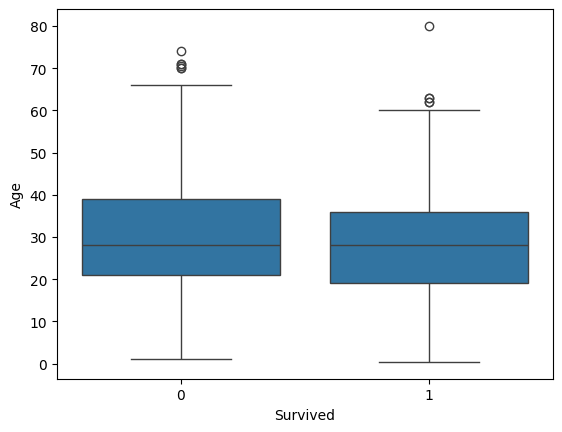

In [32]:
## numerik x kategorical
sns.boxplot(x='Survived', y='Age', data=df)
plt.show()

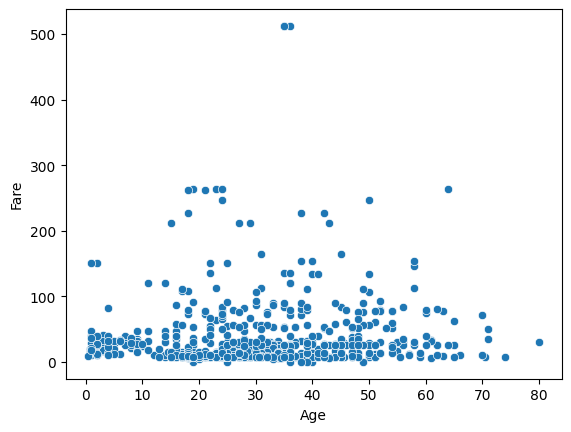

In [33]:
sns.scatterplot(x='Age', y='Fare', data=df)
plt.show()

### Correlation Analysis

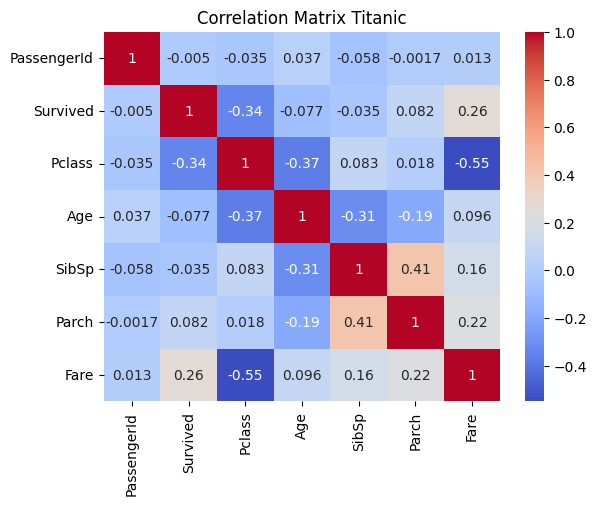

In [34]:
corr = df.corr(numeric_only=True)

#tampilkan korelasi menggunakan heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Titanic")
plt.show()

### Deteksi Outlier


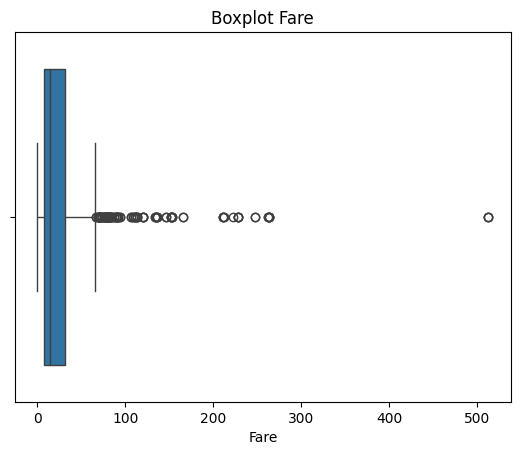

In [35]:
sns.boxplot(x=df['Fare'])
plt.title("Boxplot Fare")
plt.show()

## Data Preprocessing & Feature Engineering

### Outlier Handling

In [36]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]

print("Jumlah outlier:", len(outliers))

Jumlah outlier: 116


In [37]:
#remove
df_clean = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]

In [38]:
#capping
df['Fare_capped'] = df['Fare'].clip(lower, upper)

In [39]:
#transformasi
df['Fare_log'] = np.log(df['Fare'] + 1)

### Hasil

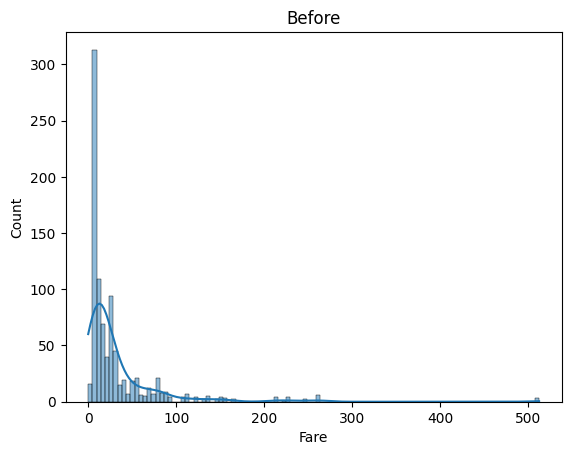

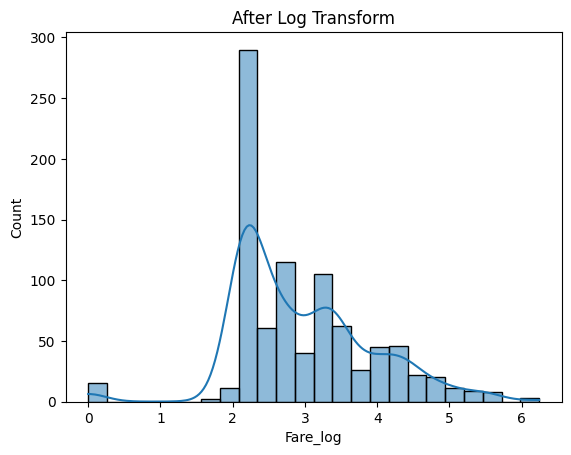

In [40]:
sns.histplot(df['Fare'], kde=True)
plt.title("Before")
plt.show()

sns.histplot(df['Fare_log'], kde=True)
plt.title("After Log Transform")
plt.show()

###Handling Missing Value

In [43]:
#hitung nilai null pada Age
df['Age'].isnull().isnull()

,Age
0,False
1,False
2,False
3,False
4,False
...,...
886,False
887,False
888,False
889,False


In [50]:
#Gunakan Mean untuk menghitung rata rata Age
df['Age'].fillna(df['Age'].mean(), inplace=True)

In [52]:
#Gunakan Median untuk melihat nilai tengah
df['Age'].fillna(df['Age'].median(), inplace=True)

###Encoding

In [ ]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

###scaling

In [54]:
#Normalisasi


scaler = MinMaxScaler()
df['Fare_norm'] = scaler.fit_transform(df[['Fare']])

In [53]:
#standarisasi


scaler = StandardScaler()
df['Fare_std'] = scaler.fit_transform(df[['Fare']])